# Pertemuan 13 - Deep Learning & NLP Dasar

- Nama: Widya Anggara
- NIM: 230401020091
- Kelas: IF401



## Generate & Eksplorasi Dataset Non-Linear

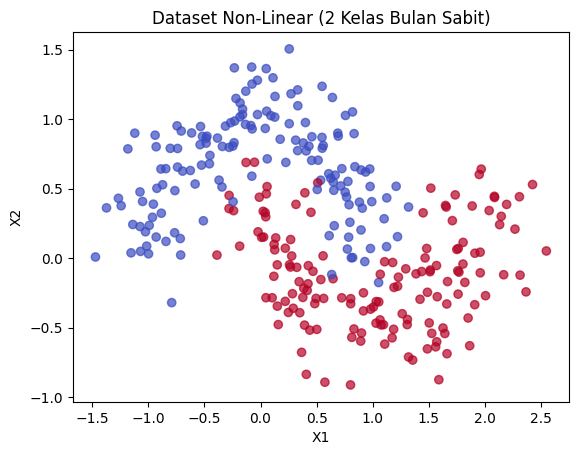

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()


## Bangun & Latih Neural Network


In [3]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

np.random.seed(42)
tf.random.set_seed(42)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Sequential([
    Input(shape=(2,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_tr, y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=0
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

## Evaluasi & Kurva Belajar


Akurasi pada data uji: 0.900


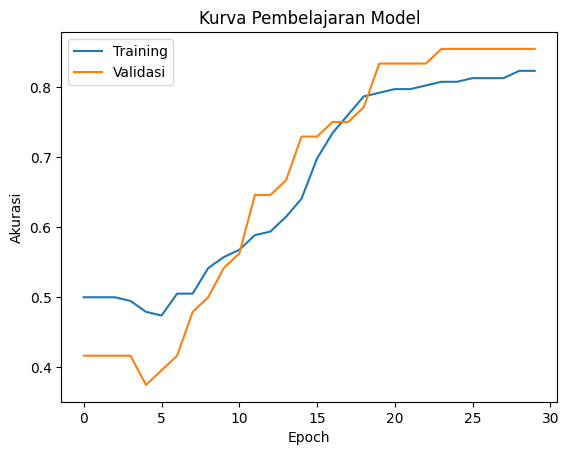

In [4]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.title('Kurva Pembelajaran Model')
plt.legend()
plt.show()


## Dataset Ulasan Produk

In [5]:
ulasan = [
    'Barang bagus, pengiriman cepat',
    'Kualitas bagus dan sesuai deskripsi',
    'Sangat puas dengan produk ini',
    'Produk bagus dan berfungsi baik',
    'Recommended, kualitasnya bagus',
    'Paket cepat sampai, saya puas',
    'Barang bagus dan nyaman digunakan',
    'Pelayanan baik dan sangat ramah',
    'Produk sesuai foto, hasilnya bagus',
    'Harga murah dan kualitas bagus',
    'Barang original, kualitas sangat baik',
    'Pengemasan baik dan barang aman',
    'Produk mudah digunakan dan bagus',
    'Desain bagus dan terlihat premium',
    'Pengiriman cepat, pelayanan baik',
    'Saya puas dengan kualitas barang',
    'Barang bekerja baik dan bagus',
    'Pengalaman belanja sangat baik',
    'Seller ramah, produk bagus',
    'Produk bagus dan memuaskan',

    'Barang jelek, pengiriman lambat',
    'Kualitas jelek dan tidak sesuai deskripsi',
    'Sangat kecewa dengan produk ini',
    'Produk jelek dan tidak berfungsi',
    'Tidak recommended, kualitasnya buruk',
    'Paket lambat sampai, saya kecewa',
    'Barang rusak dan tidak nyaman digunakan',
    'Pelayanan buruk dan tidak ramah',
    'Produk tidak sesuai foto, hasilnya jelek',
    'Harga mahal dan kualitas buruk',
    'Barang palsu, kualitas sangat jelek',
    'Pengemasan buruk dan barang rusak',
    'Produk sulit digunakan dan jelek',
    'Desain buruk dan terlihat murahan',
    'Pengiriman lambat, pelayanan buruk',
    'Saya kecewa dengan kualitas barang',
    'Barang tidak bekerja dan rusak',
    'Pengalaman belanja sangat buruk',
    'Seller tidak ramah, produk jelek',
    'Produk buruk dan mengecewakan'
]

label = [1] * 20 + [0] * 20

print('Jumlah ulasan:', len(ulasan))
print('Positif:', label.count(1))
print('Negatif:', label.count(0))


Jumlah ulasan: 40
Positif: 20
Negatif: 20


## Ubah Teks Menjadi TF-IDF


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print('Contoh kata:', tfidf.get_feature_names_out()[:15])
print('Ukuran matriks TF-IDF:', X_text.shape)


Jumlah kata unik: 51
Contoh kata: ['aman' 'bagus' 'baik' 'barang' 'bekerja' 'belanja' 'berfungsi' 'buruk'
 'cepat' 'dan' 'dengan' 'desain' 'deskripsi' 'digunakan' 'foto']
Ukuran matriks TF-IDF: (40, 51)


## Klasifikasi Sentimen & Evaluasi


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42
)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')


Akurasi model sentimen: 0.875


In [8]:
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']

pred = model_sentimen.predict(
    tfidf.transform(kalimat_baru)
)

print('Kalimat:', kalimat_baru[0])
print('Prediksi:', 'Positif' if pred[0] == 1 else 'Negatif')


Kalimat: Pelayanan sangat memuaskan dan ramah
Prediksi: Positif


In [9]:
contoh_lain = [
    'Barangnya bagus dan saya sangat puas',
    'Produk rusak dan sangat mengecewakan'
]

hasil = model_sentimen.predict(tfidf.transform(contoh_lain))

for teks, nilai in zip(contoh_lain, hasil):
    print(teks, '->', 'Positif' if nilai == 1 else 'Negatif')


Barangnya bagus dan saya sangat puas -> Positif
Produk rusak dan sangat mengecewakan -> Negatif


## Kesimpulan

Neural network dengan activation ReLU dan Sigmoid dapat digunakan untuk mempelajari pola non-linear pada dataset `make_moons`. Pada bagian NLP, TF-IDF berhasil mengubah teks ulasan menjadi data numerik sehingga Logistic Regression dapat digunakan untuk klasifikasi sentimen. Pendekatan TF-IDF cukup sederhana dan cepat untuk data teks kecil, tetapi kemampuan memahami konteksnya masih terbatas dibandingkan pendekatan NLP modern.
